In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

path = "/content/drive/MyDrive/Colab Notebooks/AI-QoSR/"
df_a = pd.read_csv(path + 'dataset_path_a.csv')
df_b = pd.read_csv(path + 'dataset_path_b.csv')
df_c = pd.read_csv(path + 'dataset_path_c.csv')
df_d = pd.read_csv(path + 'dataset_path_d.csv')

df_master_raw = pd.concat([df_a, df_b, df_c, df_d], ignore_index=True)

print(f"Total Number of Rows: {len(df_master_raw)}\n")
print("-" * 50)
print("MISSING DATA (NaN/Null) REPORT (Raw Data)")
print("-" * 50)

missing_data = df_master_raw.isnull().sum()
missing_pct = (missing_data / len(df_master_raw)) * 100

for col in df_master_raw.columns:
    if missing_data[col] > 0:
        print(f"WARNING - {col}: {missing_data[col]} missing values ({missing_pct[col]:.2f}%)")
    else:
        print(f"OK - {col}: No missing values")

print("\n" + "-" * 50)
print("INFINITE (Inf) VALUE REPORT")
print("-" * 50)
numeric_cols = df_master_raw.select_dtypes(include=[np.number]).columns
inf_data = np.isinf(df_master_raw[numeric_cols]).sum()

if inf_data.sum() == 0:
    print("OK - No infinite (inf) values found in any column.")
else:
    for col in numeric_cols:
        if inf_data[col] > 0:
            print(f"WARNING - {col}: {inf_data[col]} infinite values")

Total Number of Rows: 5688

--------------------------------------------------
MISSING DATA (NaN/Null) REPORT (Raw Data)
--------------------------------------------------
OK - timestamp: No missing values
OK - path_label: No missing values
OK - target_load_mbps: No missing values
OK - qos_class: No missing values
WARNING - avg_rtt_ms: 95 missing values (1.67%)
OK - packet_loss_pct: No missing values
OK - is_anomaly: No missing values

--------------------------------------------------
INFINITE (Inf) VALUE REPORT
--------------------------------------------------
OK - No infinite (inf) values found in any column.


In [3]:
QOS_CLASS_MAP = {'VIP': 'VIP', 'ORTA': 'MEDIUM', 'DUSUK': 'LOW'}
PATH_LABEL_MAP = {
    'yol_a_20ms': 'PathA_20ms',
    'yol_b_2ms': 'PathB_2ms',
    'yol_c_10ms': 'PathC_10ms',
    'yol_d_50ms': 'PathD_50ms',
}

df_master = df_master_raw.copy()
df_master['avg_rtt_ms'] = df_master['avg_rtt_ms'].fillna(2000.0)
df_master['qos_class'] = df_master['qos_class'].map(QOS_CLASS_MAP)
df_master['path_label'] = df_master['path_label'].map(PATH_LABEL_MAP)

print("OK - Missing RTT values successfully filled with 2000.0 ms.")
print("OK - QoS class and path labels translated to English (VIP/MEDIUM/LOW, PathA-D).")

df_encoded = pd.get_dummies(df_master, columns=['qos_class', 'path_label'], dtype=int)

print("OK - Categorical data (Class and Path) digitized using One-Hot Encoding.\n")

print("-" * 60)
print("Our New Dataset Columns (Features):")
print(list(df_encoded.columns))
print("-" * 60)

df_encoded.head(3)

OK - Missing RTT values successfully filled with 2000.0 ms.
OK - QoS class and path labels translated to English (VIP/MEDIUM/LOW, PathA-D).
OK - Categorical data (Class and Path) digitized using One-Hot Encoding.

------------------------------------------------------------
Our New Dataset Columns (Features):
['timestamp', 'target_load_mbps', 'avg_rtt_ms', 'packet_loss_pct', 'is_anomaly', 'qos_class_LOW', 'qos_class_MEDIUM', 'qos_class_VIP', 'path_label_PathA_20ms', 'path_label_PathB_2ms', 'path_label_PathC_10ms', 'path_label_PathD_50ms']
------------------------------------------------------------


,timestamp,target_load_mbps,avg_rtt_ms,packet_loss_pct,is_anomaly,qos_class_LOW,qos_class_MEDIUM,qos_class_VIP,path_label_PathA_20ms,path_label_PathB_2ms,path_label_PathC_10ms,path_label_PathD_50ms
0,2026-08-21T12:22:41,121.97,64.333,0.0,1,0,0,1,1,0,0,0
1,2026-08-21T12:22:41,121.97,64.259,0.0,0,0,1,0,1,0,0,0
2,2026-08-21T12:22:41,121.97,64.296,0.0,0,1,0,0,1,0,0,0


Calculating correlation matrix...


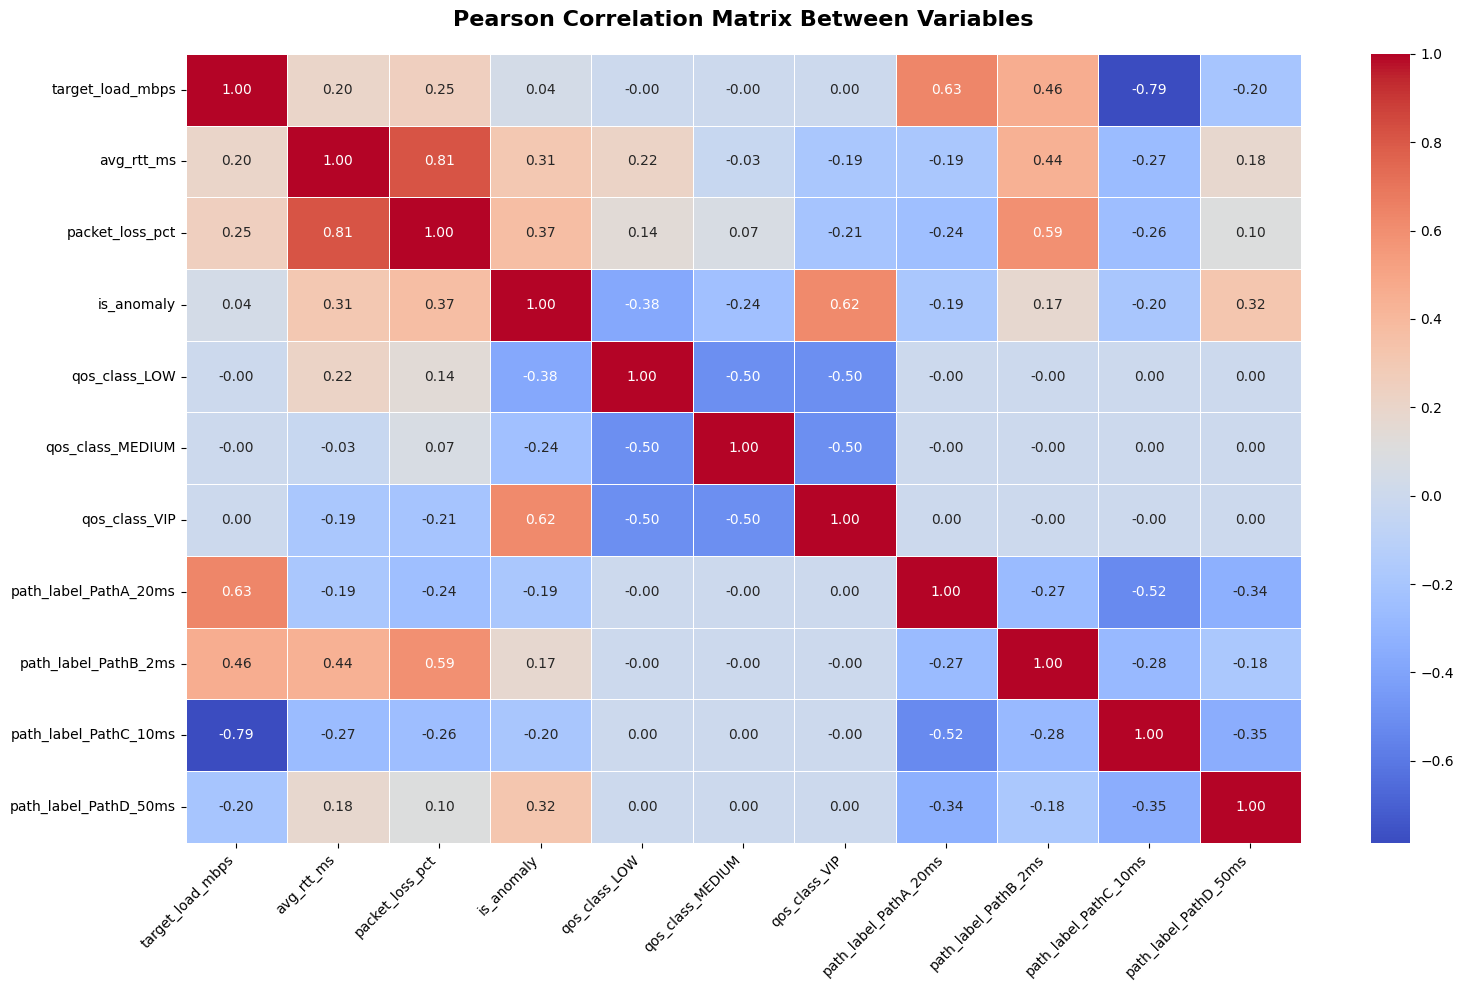


Statistical Relationships with the Target Variable ('is_anomaly') (ALL METRICS)
qos_class_VIP            0.619409
packet_loss_pct          0.371506
path_label_PathD_50ms    0.323094
avg_rtt_ms               0.308521
path_label_PathB_2ms     0.171319
target_load_mbps         0.039410
path_label_PathA_20ms   -0.186700
path_label_PathC_10ms   -0.197376
qos_class_MEDIUM        -0.240937
qos_class_LOW           -0.378472
Name: is_anomaly, dtype: float64


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Calculating correlation matrix...")

df_numeric = df_encoded.select_dtypes(include=[np.number])
corr_matrix = df_numeric.corr()

plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Pearson Correlation Matrix Between Variables', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Statistical Relationships with the Target Variable ('is_anomaly') (ALL METRICS)")
print("="*60)
anomaly_corr = corr_matrix['is_anomaly'].drop('is_anomaly').sort_values(ascending=False)
print(anomaly_corr)

In [5]:
outcome_linked_cols = ['avg_rtt_ms', 'packet_loss_pct']

cols_to_drop = [c for c in outcome_linked_cols if c in df_numeric.columns]

df_actionable = df_numeric.drop(columns=cols_to_drop)
actionable_corr = df_actionable.corr()['is_anomaly'].drop('is_anomaly').sort_values(ascending=False)

print("=" * 60)
print("Relationships with Target Variable ('is_anomaly') (DECISION-TIME FEATURES ONLY)")
print("=" * 60)
print(actionable_corr)
print("-" * 60)
print("This is the non-circular view of which QoS class/load profile is more")
print("prone to anomalies, restricted to information available at decision time.")

Relationships with Target Variable ('is_anomaly') (DECISION-TIME FEATURES ONLY)
qos_class_VIP            0.619409
path_label_PathD_50ms    0.323094
path_label_PathB_2ms     0.171319
target_load_mbps         0.039410
path_label_PathA_20ms   -0.186700
path_label_PathC_10ms   -0.197376
qos_class_MEDIUM        -0.240937
qos_class_LOW           -0.378472
Name: is_anomaly, dtype: float64
------------------------------------------------------------
This is the non-circular view of which QoS class/load profile is more
prone to anomalies, restricted to information available at decision time.


Performing 'Feature Importance' analysis (all metrics)...



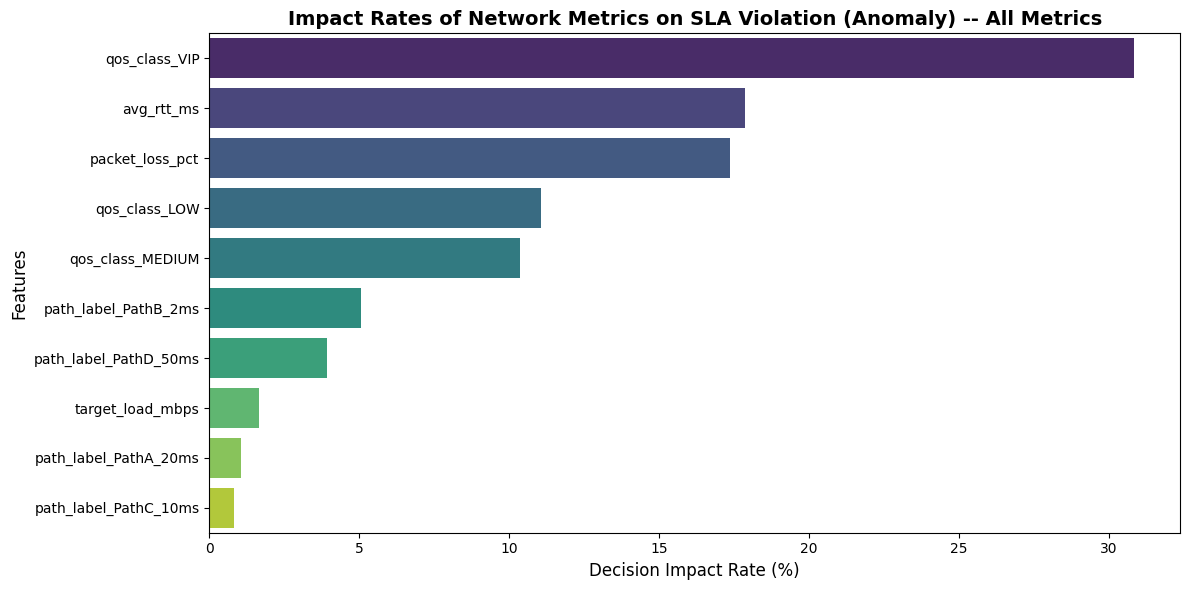

IMPACT RATES OF VARIABLES ON THE TARGET (ANOMALY) -- ALL METRICS
Feature (Network Metric)  Impact on Target (%)
           qos_class_VIP             30.832433
              avg_rtt_ms             17.874419
         packet_loss_pct             17.369010
           qos_class_LOW             11.061748
        qos_class_MEDIUM             10.363810
    path_label_PathB_2ms              5.048608
   path_label_PathD_50ms              3.918161
        target_load_mbps              1.643324
   path_label_PathA_20ms              1.047598
   path_label_PathC_10ms              0.840890

Outcome-derivative metrics such as avg_rtt_ms may appear dominant here;
the next cell excludes them to isolate decision-time features.


In [6]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Performing 'Feature Importance' analysis (all metrics)...\n")

X_importance = df_numeric.drop('is_anomaly', axis=1)
y_importance = df_numeric['is_anomaly']

rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_importance, y_importance)

feature_importances = pd.DataFrame({
    'Feature (Network Metric)': X_importance.columns,
    'Impact on Target (%)': rf_baseline.feature_importances_ * 100
}).sort_values(by='Impact on Target (%)', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Impact on Target (%)', y='Feature (Network Metric)', data=feature_importances,
            hue='Feature (Network Metric)', palette='viridis', legend=False)
plt.title('Impact Rates of Network Metrics on SLA Violation (Anomaly) -- All Metrics', fontsize=14, fontweight='bold')
plt.xlabel('Decision Impact Rate (%)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

print("=" * 60)
print("IMPACT RATES OF VARIABLES ON THE TARGET (ANOMALY) -- ALL METRICS")
print("=" * 60)
print(feature_importances.to_string(index=False))
print("\nOutcome-derivative metrics such as avg_rtt_ms may appear dominant here;")
print("the next cell excludes them to isolate decision-time features.")

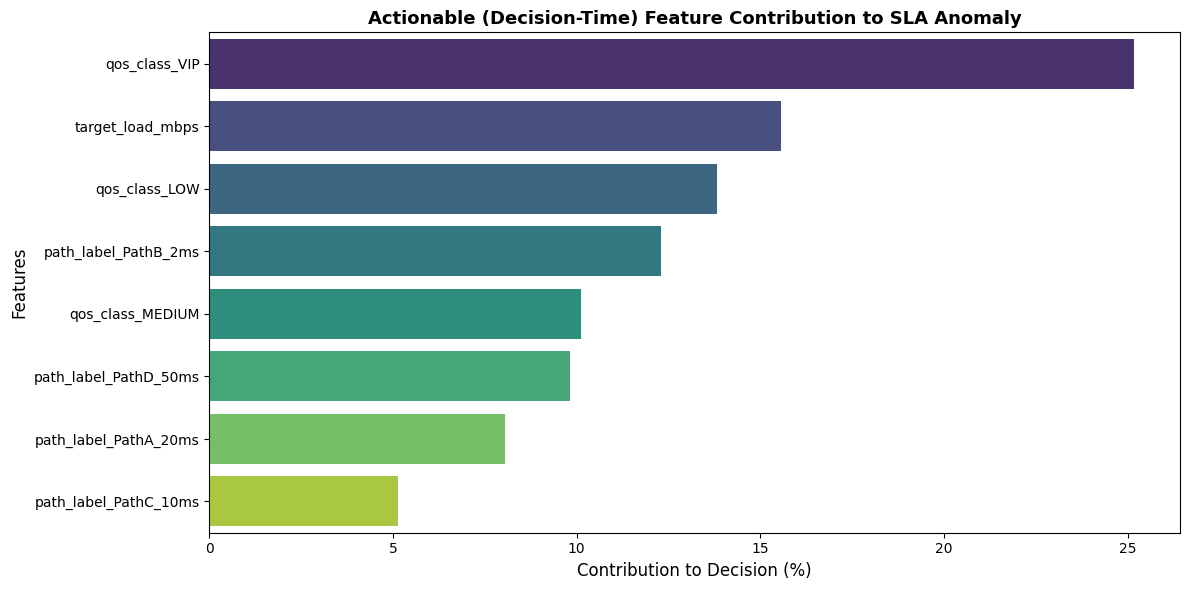

FEATURE CONTRIBUTIONS -- DECISION-TIME FEATURES ONLY
Feature (Decision-Time)  Contribution to Decision (%)
          qos_class_VIP                     25.164147
       target_load_mbps                     15.574840
          qos_class_LOW                     13.825682
   path_label_PathB_2ms                     12.300970
       qos_class_MEDIUM                     10.114243
  path_label_PathD_50ms                      9.813602
  path_label_PathA_20ms                      8.059603
  path_label_PathC_10ms                      5.146913


In [7]:
X_importance_actionable = X_importance.drop(columns=[c for c in outcome_linked_cols if c in X_importance.columns])

rf_actionable = RandomForestClassifier(n_estimators=100, random_state=42)
rf_actionable.fit(X_importance_actionable, y_importance)

feature_importances_actionable = pd.DataFrame({
    'Feature (Decision-Time)': X_importance_actionable.columns,
    'Contribution to Decision (%)': rf_actionable.feature_importances_ * 100
}).sort_values(by='Contribution to Decision (%)', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Contribution to Decision (%)', y='Feature (Decision-Time)', data=feature_importances_actionable,
            hue='Feature (Decision-Time)', palette='viridis', legend=False)
plt.title('Actionable (Decision-Time) Feature Contribution to SLA Anomaly', fontsize=13, fontweight='bold')
plt.xlabel('Contribution to Decision (%)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

print("=" * 60)
print("FEATURE CONTRIBUTIONS -- DECISION-TIME FEATURES ONLY")
print("=" * 60)
print(feature_importances_actionable.to_string(index=False))

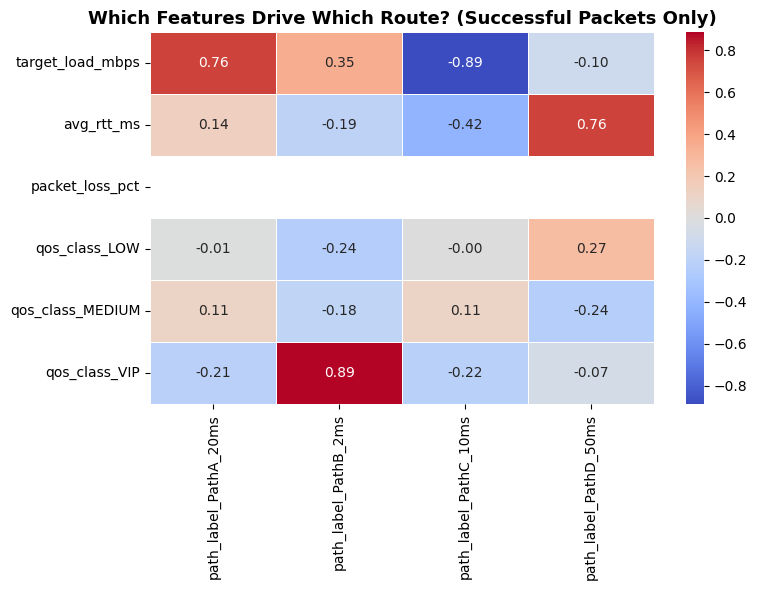

FEATURE x ROUTE CORRELATION TABLE (Successful Packets Only)
                  path_label_PathA_20ms  path_label_PathB_2ms  \
target_load_mbps                  0.760                 0.348   
avg_rtt_ms                        0.141                -0.193   
packet_loss_pct                     NaN                   NaN   
qos_class_LOW                    -0.006                -0.240   
qos_class_MEDIUM                  0.108                -0.181   
qos_class_VIP                    -0.215                 0.886   

                  path_label_PathC_10ms  path_label_PathD_50ms  
target_load_mbps                 -0.889                 -0.101  
avg_rtt_ms                       -0.418                  0.758  
packet_loss_pct                     NaN                    NaN  
qos_class_LOW                    -0.001                  0.266  
qos_class_MEDIUM                  0.107                 -0.236  
qos_class_VIP                    -0.223                 -0.067  

This table previews the asso

In [8]:
df_success = df_master[df_master['is_anomaly'] == 0].copy()

df_success_encoded = pd.get_dummies(df_success, columns=['qos_class', 'path_label'], dtype=int)
df_success_numeric = df_success_encoded.select_dtypes(include=[np.number])

path_cols = [c for c in df_success_numeric.columns if c.startswith('path_label_')]
feature_cols = [c for c in df_success_numeric.columns if c not in path_cols and c != 'is_anomaly']

route_corr = df_success_numeric[feature_cols + path_cols].corr().loc[feature_cols, path_cols]

plt.figure(figsize=(8, 6))
sns.heatmap(route_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Which Features Drive Which Route? (Successful Packets Only)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("=" * 60)
print("FEATURE x ROUTE CORRELATION TABLE (Successful Packets Only)")
print("=" * 60)
print(route_corr.round(3))
print("\nThis table previews the associations the model in Step 5 is expected to learn")
print("(e.g., qos_class_VIP -> path_label_PathB_2ms).")

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

X_all = df_numeric.drop(columns=['is_anomaly'])
y_bin = df_numeric['is_anomaly']
X_act = X_all.drop(columns=[c for c in outcome_linked_cols if c in X_all.columns])

def eval_variant(name, X):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y_bin, test_size=0.20, random_state=42, stratify=y_bin)
    clf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_tr, y_tr)
    pred = clf.predict(X_te)
    p, r, f, _ = precision_recall_fscore_support(y_te, pred, average='binary', pos_label=1)
    print(f"{name:30s} acc={accuracy_score(y_te, pred):.4f}  precision={p:.4f}  recall={r:.4f}  F1={f:.4f}")
    return y_te, pred

print("Binary SLA-anomaly classifier (positive class = anomaly), stratified 80/20 split")
eval_variant("All fields (incl. RTT, loss)", X_all)
y_te, pred = eval_variant("Decision-time fields only", X_act)
print(classification_report(y_te, pred, target_names=['compliant', 'anomaly']))

# How few rules recover the labels? (shallow tree on all fields, training accuracy)
tree = DecisionTreeClassifier(max_depth=4, random_state=42).fit(X_all, y_bin)
print("Shallow tree (depth 4) accuracy:", round(tree.score(X_all, y_bin), 4))
print(export_text(tree, feature_names=list(X_all.columns)))

Binary SLA-anomaly classifier (positive class = anomaly), stratified 80/20 split
All fields (incl. RTT, loss)   acc=1.0000  precision=1.0000  recall=1.0000  F1=1.0000
Decision-time fields only      acc=0.9402  precision=0.9394  recall=0.9323  F1=0.9358
              precision    recall  f1-score   support

   compliant       0.94      0.95      0.94       606
     anomaly       0.94      0.93      0.94       532

    accuracy                           0.94      1138
   macro avg       0.94      0.94      0.94      1138
weighted avg       0.94      0.94      0.94      1138

Shallow tree (depth 4) accuracy: 0.9945
|--- qos_class_VIP <= 0.50
|   |--- packet_loss_pct <= 10.00
|   |   |--- avg_rtt_ms <= 154.15
|   |   |   |--- avg_rtt_ms <= 99.73
|   |   |   |   |--- class: 0
|   |   |   |--- avg_rtt_ms >  99.73
|   |   |   |   |--- class: 0
|   |   |--- avg_rtt_ms >  154.15
|   |   |   |--- qos_class_LOW <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- qos_class_LOW >  0.50
|   |   |

In [9]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.base import clone
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

print("1. Preparing data for the Route Recommendation Engine...")

df_success = df_master[df_master['is_anomaly'] == 0].copy()

print(f"Total successful routing examples: {len(df_success)} rows")

FEATURE_COLS_RAW = ['qos_class', 'target_load_mbps']
X = pd.get_dummies(df_success[FEATURE_COLS_RAW], dtype=int)
FEATURE_COLUMNS = list(X.columns)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_success['path_label'])
path_names = label_encoder.classes_

QOS_COLORS = {'VIP': '#E53E3E', 'MEDIUM': '#F59E0B', 'LOW': '#2563EB'}
ROUTE_LABELS = {
    'PathA_20ms': 'Path A (20ms)',
    'PathB_2ms': 'Path B (2ms)',
    'PathC_10ms': 'Path C (10ms)',
    'PathD_50ms': 'Path D (50ms)',
}

QOS_OFFSETS = {'VIP': 0.07, 'MEDIUM': 0.0, 'LOW': -0.07}
QOS_LINESTYLES = {'VIP': '-', 'MEDIUM': '--', 'LOW': ':'}
TRAIN_MAX_LOAD = df_success['target_load_mbps'].max()

def encode_packet(qos_class, target_load_mbps, reference_columns):
    """Encode a single packet to exactly match the training column order."""
    row = pd.DataFrame([{'qos_class': qos_class, 'target_load_mbps': target_load_mbps}])
    row_encoded = pd.get_dummies(row, dtype=int)
    for col in reference_columns:
        if col not in row_encoded.columns:
            row_encoded[col] = 0
    return row_encoded[reference_columns]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

1. Preparing data for the Route Recommendation Engine...
Total successful routing examples: 3029 rows


Model Selection: Hyperparameter-Optimized Comparison (5-fold Stratified CV)
XGBoost               : 0.9498 ± 0.0063  | best params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
Random Forest         : 0.9713 ± 0.0083  | best params: {'max_depth': 15, 'min_samples_leaf': 1, 'n_estimators': 100}
Logistic Regression   : 0.9473 ± 0.0079  | best params: {'C': 1}
Decision Tree         : 0.9736 ± 0.0082  | best params: {'max_depth': None, 'min_samples_leaf': 1}
SVM                   : 0.9466 ± 0.0032  | best params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
KNN                   : 0.9708 ± 0.0072  | best params: {'n_neighbors': 3, 'weights': 'distance'}

Decision Boundary Stability Check (fewer transitions = more stable)
XGBoost               :  23 total transitions  (VIP=1, MEDIUM=8, LOW=14)
Random Forest         :  54 total transitions  (VIP=9, MEDIUM=13, LOW=32)
Logistic Regression   :   5 total transitions  (VIP=2, MEDIUM=1, LOW

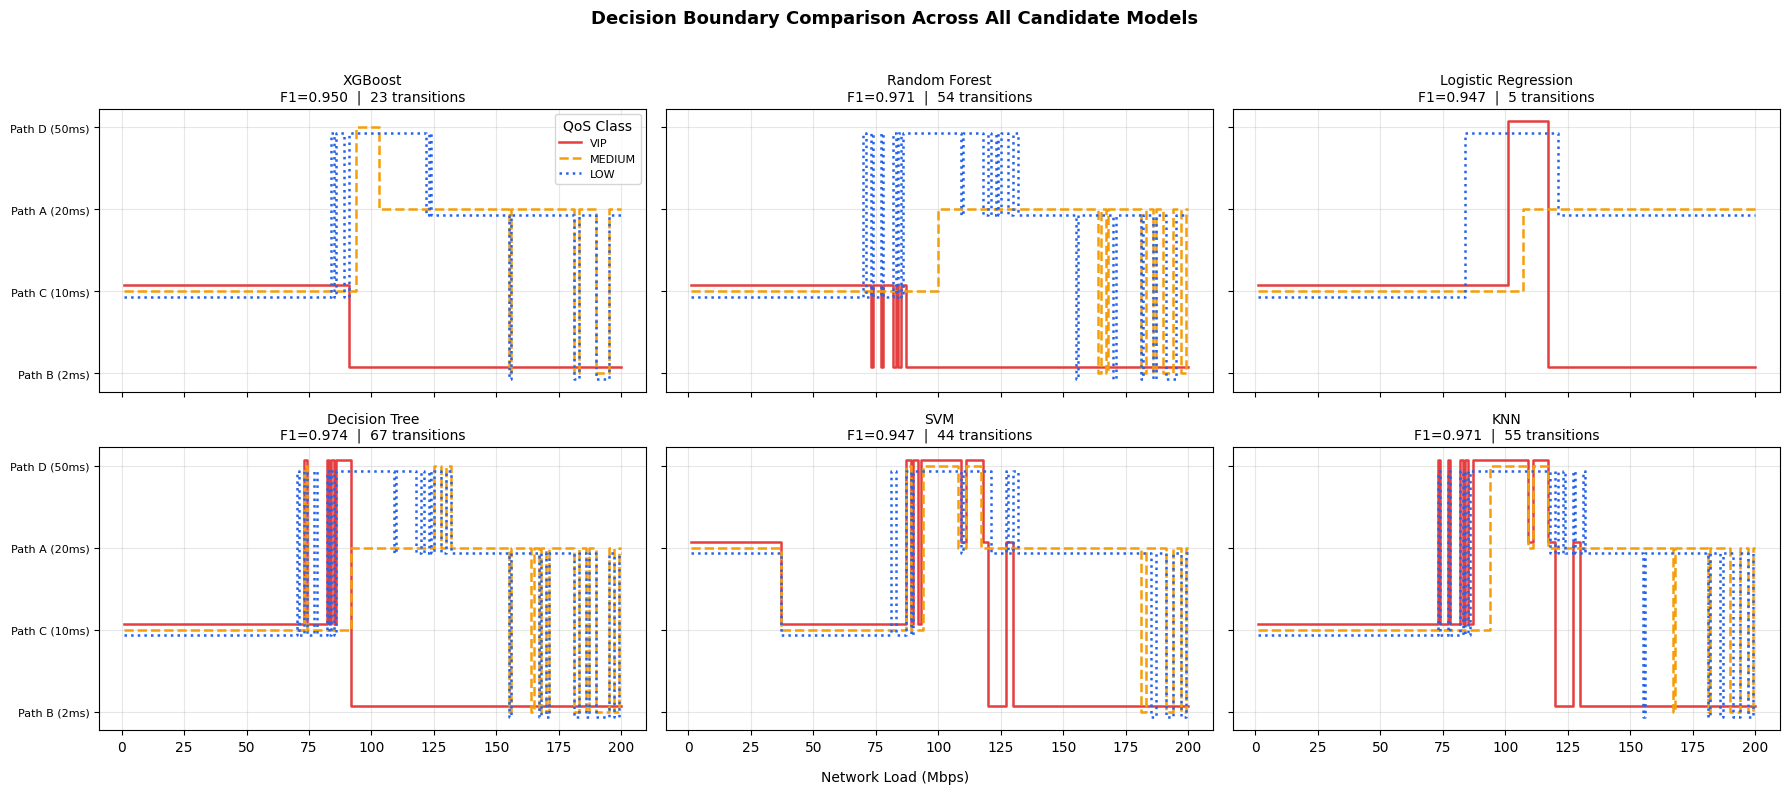


Models statistically tied with the top CV score (0.9736 ± 0.0082): ['Random Forest', 'Decision Tree', 'KNN']
Selected model (most stable boundary among statistically tied top performers): Random Forest
  -> F1 = 0.9713, transitions = 54


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

model_configs = {
    'XGBoost': (
        xgb.XGBClassifier(objective='multi:softmax', num_class=len(path_names),
                           random_state=42, eval_metric='mlogloss'),
        {'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7],
         'learning_rate': [0.05, 0.1, 0.2],
         'subsample': [0.8, 1.0], 'colsample_bytree': [0.8, 1.0]}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [100, 200, 300], 'max_depth': [None, 5, 10, 15],
         'min_samples_leaf': [1, 2, 4]}
    ),
    'Logistic Regression': (
        LogisticRegression(max_iter=2000, random_state=42),
        {'C': [0.01, 0.1, 1, 10, 100]}
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=42),
        {'max_depth': [3, 5, 7, 10, None], 'min_samples_leaf': [1, 2, 4]}
    ),
    'SVM': (
        SVC(random_state=42),
        {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 'auto']}
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance']}
    ),
}

print("Model Selection: Hyperparameter-Optimized Comparison (5-fold Stratified CV)")
print("=" * 75)
model_results = {}
for name, (estimator, grid_params) in model_configs.items():
    search = GridSearchCV(estimator, grid_params, cv=cv, scoring='f1_weighted', n_jobs=-1)
    search.fit(X, y)
    cv_check = cross_val_score(search.best_estimator_, X, y, cv=cv, scoring='f1_weighted')
    model_results[name] = {
        'best_estimator': search.best_estimator_,
        'best_params': search.best_params_,
        'mean_f1': cv_check.mean(),
        'std_f1': cv_check.std(),
    }
    print(f"{name:22s}: {cv_check.mean():.4f} ± {cv_check.std():.4f}  | best params: {search.best_params_}")

route_order_by_latency = ['PathB_2ms', 'PathC_10ms', 'PathA_20ms', 'PathD_50ms']
route_order_by_latency = [r for r in route_order_by_latency if r in path_names] + \
                          [r for r in path_names if r not in route_order_by_latency]
route_position = {r: i for i, r in enumerate(route_order_by_latency)}
load_sweep = np.arange(1, int(TRAIN_MAX_LOAD) + 1, 1)

print("\nDecision Boundary Stability Check (fewer transitions = more stable)")
print("=" * 75)
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True, sharey=True)
for ax, (name, res) in zip(axes.flat, model_results.items()):
    model = res['best_estimator']
    total_transitions = 0
    per_class_transitions = {}
    for qos in ['VIP', 'MEDIUM', 'LOW']:
        X_sweep = pd.concat([encode_packet(qos, load, FEATURE_COLUMNS) for load in load_sweep], ignore_index=True)
        preds = label_encoder.inverse_transform(model.predict(X_sweep))
        changes = int((preds[1:] != preds[:-1]).sum())
        per_class_transitions[qos] = changes
        total_transitions += changes
        pos = np.array([route_position[r] for r in preds]) + QOS_OFFSETS.get(qos, 0)
        ax.step(load_sweep, pos, where='post', linewidth=1.8,
                linestyle=QOS_LINESTYLES.get(qos, '-'), color=QOS_COLORS.get(qos, None),
                label=qos)
    res['transitions'] = total_transitions
    ax.set_title(f"{name}\nF1={res['mean_f1']:.3f}  |  {total_transitions} transitions", fontsize=10)
    ax.set_yticks(list(route_position.values()))
    ax.set_yticklabels([ROUTE_LABELS.get(r, r) for r in route_position.keys()], fontsize=8)
    ax.grid(True, alpha=0.3)
    print(f"{name:22s}: {total_transitions:3d} total transitions  "
          f"(VIP={per_class_transitions['VIP']}, MEDIUM={per_class_transitions['MEDIUM']}, LOW={per_class_transitions['LOW']})")

axes.flat[0].legend(fontsize=8, title='QoS Class')
fig.suptitle('Decision Boundary Comparison Across All Candidate Models', fontweight='bold', fontsize=13)
fig.text(0.5, 0.015, 'Network Load (Mbps)', ha='center')
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

top_name = max(model_results, key=lambda k: model_results[k]['mean_f1'])
tolerance = model_results[top_name]['std_f1']
threshold = model_results[top_name]['mean_f1'] - tolerance
competitive = [n for n, r in model_results.items() if r['mean_f1'] >= threshold]

print(f"\nModels statistically tied with the top CV score "
      f"({model_results[top_name]['mean_f1']:.4f} ± {tolerance:.4f}): {competitive}")
best_model_name = min(competitive, key=lambda n: model_results[n]['transitions'])
print(f"Selected model (most stable boundary among statistically tied top performers): {best_model_name}")
print(f"  -> F1 = {model_results[best_model_name]['mean_f1']:.4f}, transitions = {model_results[best_model_name]['transitions']}")


Training the final model using: Random Forest
Training complete! Route engine ready.

Model Performance Evaluation (Single Test Split)

--- ROUTE RECOMMENDATION REPORT ---
               precision    recall  f1-score   support

Path A (20ms)       0.97      0.98      0.98       255
 Path B (2ms)       0.95      0.84      0.89        45
Path C (10ms)       0.99      1.00      0.99       266
Path D (50ms)       0.92      0.90      0.91        40

     accuracy                           0.97       606
    macro avg       0.96      0.93      0.94       606
 weighted avg       0.97      0.97      0.97       606



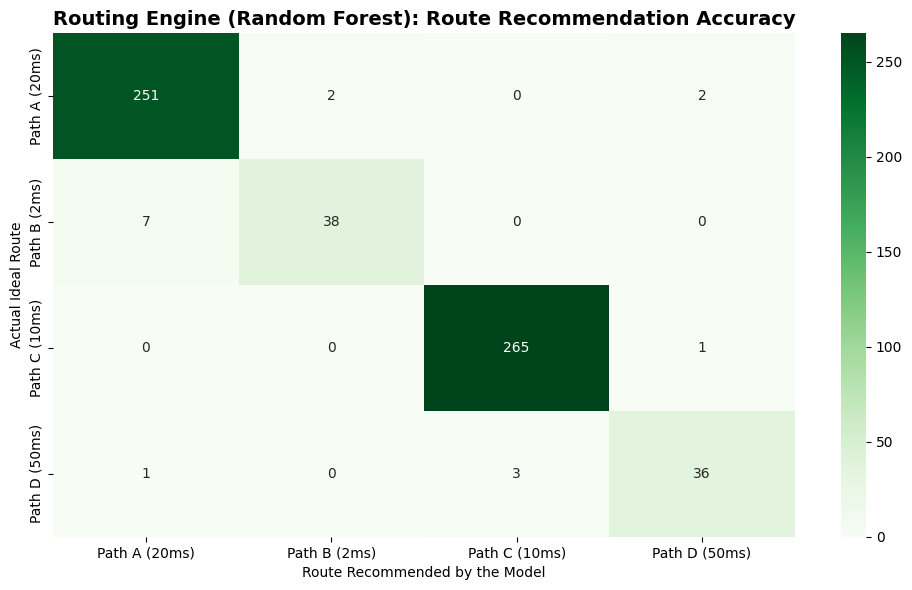


5-Fold Stratified Cross-Validation (Robustness Check)
Weighted F1 (5-fold CV): 0.9713 ± 0.0083
Fold scores: [0.9622 0.9763 0.9851 0.9664 0.9662]
LIVE TEST (SDN CONTROLLER SIMULATION)
Packet arriving at the Ryu Controller: VIP (50 Mbps)
Routing Decision: >> Path C (10ms) <<

Model (Random Forest), encoder, and feature order (.pkl) successfully exported.


In [11]:
print(f"\nTraining the final model using: {best_model_name}")
model_router = clone(model_results[best_model_name]['best_estimator'])
model_router.fit(X_train, y_train)
print("Training complete! Route engine ready.\n")

print("Model Performance Evaluation (Single Test Split)")
y_pred = model_router.predict(X_test)
print("\n--- ROUTE RECOMMENDATION REPORT ---")
print(classification_report(y_test, y_pred, target_names=[ROUTE_LABELS.get(p, p) for p in path_names]))

plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=[ROUTE_LABELS.get(p, p) for p in path_names],
            yticklabels=[ROUTE_LABELS.get(p, p) for p in path_names])
plt.title(f'Routing Engine ({best_model_name}): Route Recommendation Accuracy',
          fontweight='bold', fontsize=14)
plt.xlabel('Route Recommended by the Model')
plt.ylabel('Actual Ideal Route')
plt.tight_layout()
plt.show()

print("\n5-Fold Stratified Cross-Validation (Robustness Check)")
cv_scores = cross_val_score(model_router, X, y, cv=cv, scoring='f1_weighted')
print(f"Weighted F1 (5-fold CV): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Fold scores: {np.round(cv_scores, 4)}")

print("=" * 50)
print("LIVE TEST (SDN CONTROLLER SIMULATION)")
print("=" * 50)

def encode_packet(qos_class, target_load_mbps, reference_columns):
    """Encode a single packet to exactly match the training column order."""
    row = pd.DataFrame([{'qos_class': qos_class, 'target_load_mbps': target_load_mbps}])
    row_encoded = pd.get_dummies(row, dtype=int)
    for col in reference_columns:
        if col not in row_encoded.columns:
            row_encoded[col] = 0
    return row_encoded[reference_columns]

sample_packet = encode_packet('VIP', 50, FEATURE_COLUMNS)
predicted_route_idx = model_router.predict(sample_packet)[0]
predicted_route_name = label_encoder.inverse_transform([predicted_route_idx])[0]
print(f"Packet arriving at the Ryu Controller: VIP (50 Mbps)")
print(f"Routing Decision: >> {ROUTE_LABELS.get(predicted_route_name, predicted_route_name)} <<")

joblib.dump(model_router, 'ai_qosr_router_model.pkl')
joblib.dump(label_encoder, 'ai_qosr_label_encoder.pkl')
joblib.dump(FEATURE_COLUMNS, 'ai_qosr_feature_columns.pkl')
print(f"\nModel ({best_model_name}), encoder, and feature order (.pkl) successfully exported.")

In [12]:
import pandas as pd

scenarios = [
    {'Scenario': 'VIP - Very Low Load', 'target_load_mbps': 5, 'qos_class': 'VIP'},
    {'Scenario': 'VIP - Standard Load', 'target_load_mbps': 40, 'qos_class': 'VIP'},
    {'Scenario': 'VIP - Heavy Load', 'target_load_mbps': 100, 'qos_class': 'VIP'},
    {'Scenario': 'VIP - High Load (Realistic Ceiling)', 'target_load_mbps': 180, 'qos_class': 'VIP'},

    {'Scenario': 'MEDIUM - Very Low Load', 'target_load_mbps': 10, 'qos_class': 'MEDIUM'},
    {'Scenario': 'MEDIUM - Standard Load', 'target_load_mbps': 50, 'qos_class': 'MEDIUM'},
    {'Scenario': 'MEDIUM - Heavy Load', 'target_load_mbps': 120, 'qos_class': 'MEDIUM'},
    {'Scenario': 'MEDIUM - High Load (Realistic Ceiling)', 'target_load_mbps': 190, 'qos_class': 'MEDIUM'},

    {'Scenario': 'LOW - Very Low Load', 'target_load_mbps': 15, 'qos_class': 'LOW'},
    {'Scenario': 'LOW - Standard Load', 'target_load_mbps': 80, 'qos_class': 'LOW'},
    {'Scenario': 'LOW - Heavy Load', 'target_load_mbps': 150, 'qos_class': 'LOW'},
    {'Scenario': 'LOW - High Load (Realistic Ceiling)', 'target_load_mbps': 195, 'qos_class': 'LOW'},
]

df_scenarios = pd.DataFrame(scenarios)

TRAIN_MAX_LOAD = df_success['target_load_mbps'].max()
out_of_range = df_scenarios[df_scenarios['target_load_mbps'] > TRAIN_MAX_LOAD]
if len(out_of_range) > 0:
    print(f"WARNING: The following scenarios exceed the observed maximum of the")
    print(f"training data ({TRAIN_MAX_LOAD:.1f} Mbps) -- the model will extrapolate here:")
    print(out_of_range[['Scenario', 'target_load_mbps']].to_string(index=False))
else:
    print(f"All scenarios are within the observed training range (max {TRAIN_MAX_LOAD:.1f} Mbps).")

X_new = pd.concat(
    [encode_packet(row['qos_class'], row['target_load_mbps'], FEATURE_COLUMNS)
     for _, row in df_scenarios.iterrows()],
    ignore_index=True
)

predicted_encoded = model_router.predict(X_new)
predicted_routes = label_encoder.inverse_transform(predicted_encoded)

results = pd.DataFrame({
    'Scenario Type': df_scenarios['Scenario'],
    'QoS Class': df_scenarios['qos_class'],
    'Incoming Load': df_scenarios['target_load_mbps'].astype(str) + " Mbps",
    'Route Decision': [ROUTE_LABELS.get(r, r) for r in predicted_routes]
})

print("=" * 80)
print("STRESS TEST AND NEW SCENARIOS (Routing Reflexes)")
print("=" * 80)
print(results.to_string(index=False))
print("=" * 80)

All scenarios are within the observed training range (max 200.0 Mbps).
STRESS TEST AND NEW SCENARIOS (Routing Reflexes)
                         Scenario Type QoS Class Incoming Load Route Decision
                   VIP - Very Low Load       VIP        5 Mbps  Path C (10ms)
                   VIP - Standard Load       VIP       40 Mbps  Path C (10ms)
                      VIP - Heavy Load       VIP      100 Mbps   Path B (2ms)
   VIP - High Load (Realistic Ceiling)       VIP      180 Mbps   Path B (2ms)
                MEDIUM - Very Low Load    MEDIUM       10 Mbps  Path C (10ms)
                MEDIUM - Standard Load    MEDIUM       50 Mbps  Path C (10ms)
                   MEDIUM - Heavy Load    MEDIUM      120 Mbps  Path A (20ms)
MEDIUM - High Load (Realistic Ceiling)    MEDIUM      190 Mbps   Path B (2ms)
                   LOW - Very Low Load       LOW       15 Mbps  Path C (10ms)
                   LOW - Standard Load       LOW       80 Mbps  Path C (10ms)
                      

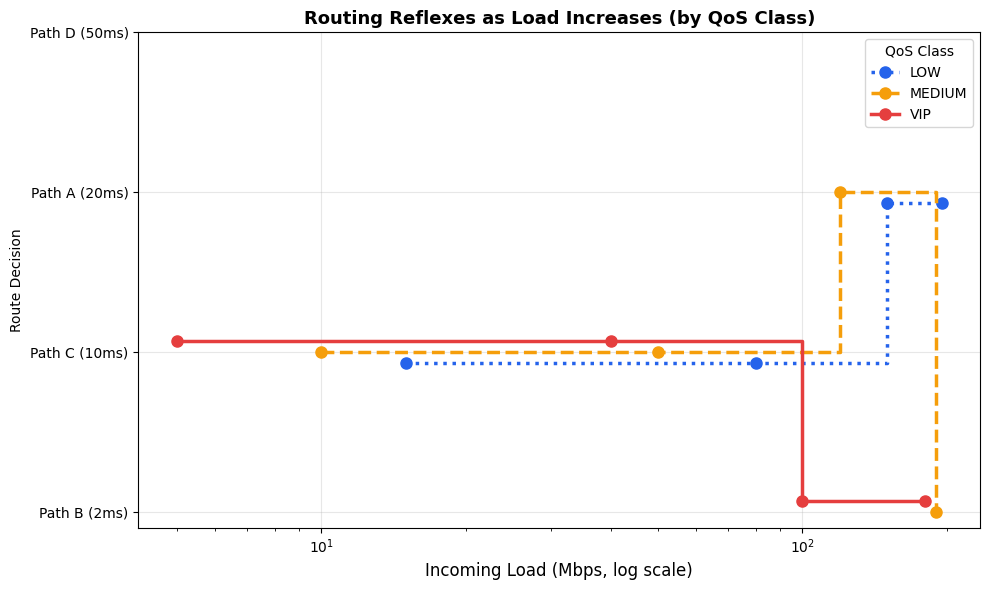

This chart shows that the VIP class switches to Path B (premium) somewhere
in the 40-100 Mbps range, and that Path D (risky) is never selected in
any of the tested scenarios.


In [13]:
route_order_by_latency = ['PathB_2ms', 'PathC_10ms', 'PathA_20ms', 'PathD_50ms']
route_order_by_latency = [r for r in route_order_by_latency if r in path_names] + \
                          [r for r in path_names if r not in route_order_by_latency]
route_position = {r: i for i, r in enumerate(route_order_by_latency)}

df_plot = df_scenarios.copy()
df_plot['Route'] = predicted_routes
df_plot['Route_Pos'] = df_plot['Route'].map(route_position)

plt.figure(figsize=(10, 6))
for qos, grp in df_plot.groupby('qos_class'):
    grp_sorted = grp.sort_values('target_load_mbps')
    plt.step(grp_sorted['target_load_mbps'], grp_sorted['Route_Pos'] + QOS_OFFSETS.get(qos, 0), where='post',
              marker='o', markersize=8, linewidth=2.5,
              linestyle=QOS_LINESTYLES.get(qos, '-'),
              color=QOS_COLORS.get(qos, None), label=qos)

plt.xscale('log')
plt.xlabel('Incoming Load (Mbps, log scale)', fontsize=12)
plt.ylabel('Route Decision')
plt.yticks(list(route_position.values()), [ROUTE_LABELS.get(r, r) for r in route_position.keys()])
plt.title('Routing Reflexes as Load Increases (by QoS Class)', fontsize=13, fontweight='bold')
plt.legend(title='QoS Class')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("This chart shows that the VIP class switches to Path B (premium) somewhere")
print("in the 40-100 Mbps range, and that Path D (risky) is never selected in")
print("any of the tested scenarios.")

In [14]:
print("Load distribution of packets labeled as Path B (PathB_2ms) that were SUCCESSFUL:")
print(df_success[df_success['path_label'] == 'PathB_2ms']['target_load_mbps'].describe())
print("\nThis range reflects the generator's ambient congestion level, not Path B's")
print("physical capacity (see the general TRAIN_MAX_LOAD check in Step 6.3, ~200 Mbps).")

Load distribution of packets labeled as Path B (PathB_2ms) that were SUCCESSFUL:
count    227.000000
mean     170.475286
std       18.789576
min      121.270000
25%      159.855000
50%      172.160000
75%      186.595000
max      200.000000
Name: target_load_mbps, dtype: float64

This range reflects the generator's ambient congestion level, not Path B's
physical capacity (see the general TRAIN_MAX_LOAD check in Step 6.3, ~200 Mbps).


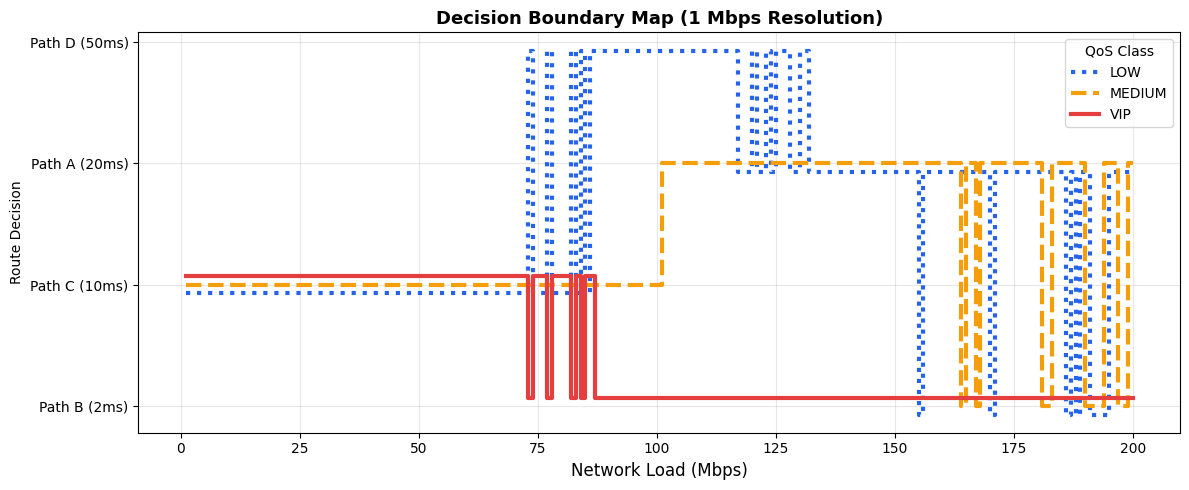

Detected route transition points (1 Mbps resolution):

VIP:
  from 1 Mbps -> Path C (10ms)
  from 73 Mbps -> Path B (2ms)
  from 74 Mbps -> Path C (10ms)
  from 77 Mbps -> Path B (2ms)
  from 78 Mbps -> Path C (10ms)
  from 82 Mbps -> Path B (2ms)
  from 83 Mbps -> Path C (10ms)
  from 84 Mbps -> Path B (2ms)
  from 85 Mbps -> Path C (10ms)
  from 87 Mbps -> Path B (2ms)
  9 transitions detected -- the decision boundary may be noisy,
  likely due to the non-smooth decision surface of this tree-based model.

MEDIUM:
  from 1 Mbps -> Path C (10ms)
  from 101 Mbps -> Path A (20ms)
  from 164 Mbps -> Path B (2ms)
  from 165 Mbps -> Path A (20ms)
  from 167 Mbps -> Path B (2ms)
  from 168 Mbps -> Path A (20ms)
  from 181 Mbps -> Path B (2ms)
  from 183 Mbps -> Path A (20ms)
  from 190 Mbps -> Path B (2ms)
  from 194 Mbps -> Path A (20ms)
  from 197 Mbps -> Path B (2ms)
  from 199 Mbps -> Path A (20ms)
  11 transitions detected -- the decision boundary may be noisy,
  likely due to the non-s

In [15]:
load_sweep = np.arange(1, int(TRAIN_MAX_LOAD) + 1, 1)
sweep_rows = []
for qos in ['VIP', 'MEDIUM', 'LOW']:
    X_sweep = pd.concat(
        [encode_packet(qos, load, FEATURE_COLUMNS) for load in load_sweep],
        ignore_index=True
    )
    preds = label_encoder.inverse_transform(model_router.predict(X_sweep))
    for load, route in zip(load_sweep, preds):
        sweep_rows.append({'qos_class': qos, 'target_load_mbps': load, 'route': route})

df_sweep = pd.DataFrame(sweep_rows)

route_order_by_latency = ['PathB_2ms', 'PathC_10ms', 'PathA_20ms', 'PathD_50ms']
route_order_by_latency = [r for r in route_order_by_latency if r in path_names] + \
                          [r for r in path_names if r not in route_order_by_latency]
route_position = {r: i for i, r in enumerate(route_order_by_latency)}
df_sweep['route_pos'] = df_sweep['route'].map(route_position)

plt.figure(figsize=(12, 5))
for qos, grp in df_sweep.groupby('qos_class'):
    grp_sorted = grp.sort_values('target_load_mbps')
    plt.step(grp_sorted['target_load_mbps'], grp_sorted['route_pos'] + QOS_OFFSETS.get(qos, 0), where='post',
              linewidth=3, linestyle=QOS_LINESTYLES.get(qos, '-'),
              color=QOS_COLORS.get(qos, None), label=qos)

plt.xlabel('Network Load (Mbps)', fontsize=12)
plt.ylabel('Route Decision')
plt.yticks(list(route_position.values()), [ROUTE_LABELS.get(r, r) for r in route_position.keys()])
plt.title('Decision Boundary Map (1 Mbps Resolution)', fontsize=13, fontweight='bold')
plt.legend(title='QoS Class')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Detected route transition points (1 Mbps resolution):")
for qos in ['VIP', 'MEDIUM', 'LOW']:
    sub = df_sweep[df_sweep['qos_class'] == qos].sort_values('target_load_mbps').reset_index(drop=True)
    changes = sub[sub['route'] != sub['route'].shift(1)]
    print(f"\n{qos}:")
    for _, row in changes.iterrows():
        print(f"  from {int(row['target_load_mbps'])} Mbps -> {ROUTE_LABELS.get(row['route'], row['route'])}")
    if len(changes) > 3:
        print(f"  {len(changes)-1} transitions detected -- the decision boundary may be noisy,")
        print(f"  likely due to the non-smooth decision surface of this tree-based model.")

print("\n" + "=" * 60)
print("Summary")
print("=" * 60)
print("The transition points above show how each QoS class's route preference")
print("shifts as network load increases. VIP switches to the low-latency path")
print("at the lowest load threshold among the three classes, reflecting its")
print("strict delay requirement. All three classes show some boundary noise in")
print("narrow load bands (see exact Mbps values above) -- likely reflecting")
print("locally sparse training coverage -- and this should be reported as a")
print("known limitation rather than a clean, monotonic decision rule.")